# TSP (Travelling Salesman Problem)

## Importation des algorithmes

In [17]:

from algo import algorithme, algorithme2
from utils import *
from algo.aco import aco_solve, format_solution


### Déclaration des variables

In [18]:
random_n = 300 # Nombre de points de livraison
ratio_express = 0.4 # Ratio des points de livraison express
points = make_demo_points(random_n, ratio_express)

alpha = 1.0 # Influence la durée globale du tour
beta = 1.0 # Influence la priorité des clients
max_hours = 8.0 # Durée maximale de la tournée (8 h)
speed = 30 # Convertit les distances en heures de trajet

n_express = sum(point.est_express for point in points)
w_express = ((random_n - n_express - 1)/(random_n - (random_n - n_express - 1))) + 1 # Importance des clients prioritaires
w_normal = 1/(1 + w_express) # Importance des clients standards

## Utilisation des différents algorithmes pour résoudre TSP

### Algorithme 1 Backbone express + insertion gloutonne par rapport à I des normals


--- Résultats ---
Tour (indices): [0, 100, 177, 115, 5, 212, 208, 228, 198, 18, 15, 227, 57, 79, 16, 173, 154, 197, 161, 165, 32, 170, 276, 42, 132, 1, 220, 157, 144, 195, 3, 86, 92, 235, 59, 255, 50, 20, 207, 8, 166, 17, 117, 142, 35, 178, 19, 40, 272, 98, 138, 125, 61, 179, 274, 162, 284, 176, 181, 116, 45, 104, 265, 96, 39, 68, 189, 175, 180, 226, 94, 14, 73, 75, 209, 203, 206, 163, 172, 254, 114, 236, 123, 204, 184, 126, 285, 287, 31, 93, 62, 85, 169, 109, 289, 10, 112, 107, 77, 145, 55, 293, 65, 87, 103, 199, 147, 267, 150, 140, 216, 118, 252, 174, 242, 277, 291, 288, 141, 297, 53, 270, 188, 38, 60, 224, 134, 64, 271, 240, 129, 97, 294, 69, 269, 167, 239, 30, 52, 102, 164, 95, 243, 121, 111, 63, 91, 44, 248, 25, 88, 9, 12, 183, 256, 260, 124, 101, 66, 149, 131, 190, 90, 51, 21, 148, 33, 211, 106, 219, 266, 279, 191, 231, 246, 76, 205, 58, 193, 250, 158, 217, 253, 122, 221, 48, 6, 262, 298, 49, 29, 290, 237, 120, 200, 23, 139, 213, 136, 54, 105, 258, 24, 230, 152, 27, 128, 84, 155

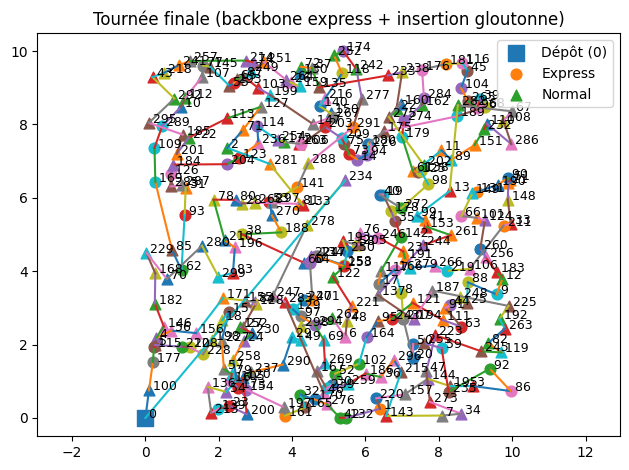

In [20]:
t_arr_1, tour_with_types_1 = algorithme.run(points, alpha, beta, w_express, w_normal, max_hours, speed)

### Algorithme 2 Concaténation christophides sur express + christophides sur normals


=== DÉBUT TSP PONDÉRÉ ===
Dépôt : Point(x=0.0, y=0.0, est_express=False)
Points express (107): [1, 8, 9, 14, 15, 16, 17, 19, 20, 23, 30, 32, 35, 38, 39, 40, 42, 44, 45, 50, 52, 53, 59, 62, 63, 64, 66, 68, 73, 75, 77, 86, 88, 90, 92, 93, 94, 96, 97, 98, 102, 104, 109, 114, 115, 116, 118, 123, 125, 126, 129, 131, 132, 134, 138, 139, 140, 141, 142, 154, 158, 161, 164, 165, 166, 169, 170, 173, 174, 176, 177, 178, 179, 180, 181, 188, 189, 203, 204, 206, 207, 208, 209, 211, 212, 217, 219, 220, 228, 235, 239, 240, 243, 246, 250, 253, 260, 265, 267, 271, 272, 274, 284, 289, 291, 293, 294]
Points normaux (192): [2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 18, 21, 22, 24, 25, 26, 27, 28, 29, 31, 33, 34, 36, 37, 41, 43, 46, 47, 48, 49, 51, 54, 55, 56, 57, 58, 60, 61, 65, 67, 69, 70, 71, 72, 74, 76, 78, 79, 80, 81, 82, 83, 84, 85, 87, 89, 91, 95, 99, 100, 101, 103, 105, 106, 107, 108, 110, 111, 112, 113, 117, 119, 120, 121, 122, 124, 127, 128, 130, 133, 135, 136, 137, 143, 144, 145, 146, 147, 148, 149, 150

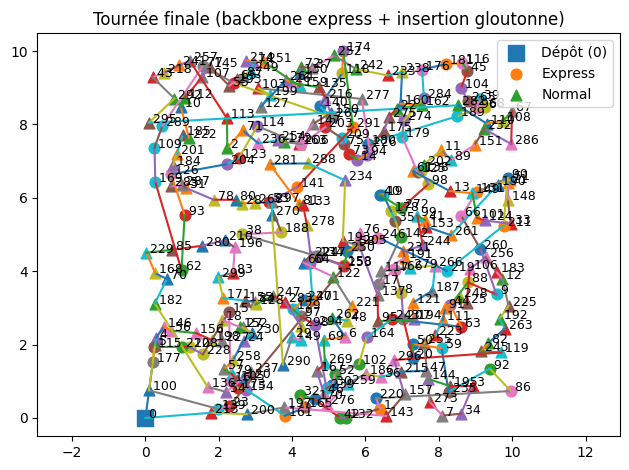

In [19]:
t_arr_2,tour_with_types_2 = algorithme2.run(points, alpha, beta, w_express, w_normal, max_hours, speed)

## Analyse des indicateurs de performance entre nos deux algorithme

In [24]:
epi_1 = compute_epi(tour_with_types_1, w_express, random_n)  
epi_2 = compute_epi(tour_with_types_2, w_normal, random_n)

du_1 = t_arr_1[-1]/max_hours
du_2 = t_arr_2[-1]/max_hours

print(f"Algorithme 1: EPI = {epi_1:.3f}, DU = {du_1:.3f}")
print(f"Algorithme 2: EPI = {epi_2:.3f}, DU = {du_2:.3f}")

Algorithme 1: EPI = 0.718, DU = 0.796
Algorithme 2: EPI = 0.819, DU = 0.960


### Conclusion
L'algorithme 1 est plus complet car certe son EPI (Express Priority Index, PS: est expliqué dans utils fonction compute_epi) est moins proche de 1 que de l'algorithme 2, mais reste élevé et de plus DU (Duration Usage tout simplement le rapport de la durée finale sur la durée totale) est plus faible, ce qui veut dire que niveau logistique et priorité des clients express, on est plutôt équilibré.

Donc il est préférable de favoriser l'utilisation de l'algorithme 1 qui permettra de livré plus de colis tout en priorisant les express sans non plus les livrés en premier comme fait l'algorithme 2.

## Méta Heuristique

In [23]:
sol = aco_solve(
    points,
    alpha=alpha,
    beta=beta,
    speed=speed,
    max_hours=max_hours,
    ants=len(points),        # raisonnable: ~n
    iterations=250,          # augmente pour de meilleurs résultats
    rho=0.4,
    Q=1.0,
    seed=1,
    # Optionnel: surpondérer les express si tu veux insister encore plus
    # w_express=3.0, w_normal=1.0,
)

print(format_solution(sol, points))

Objectif I = 5973.218
Temps total T = 10.008 h ; distance = 300.232 unités
Ordre de visite (indices): 0 -> 212 -> 156 -> 228 -> 208 -> 213 -> 139 -> 23 -> 136 -> 100 -> 5 -> 115 -> 4 -> 146 -> 70 -> 168 -> 229 -> 299 -> 171 -> 18 -> 54 -> 56 -> 198 -> 227 -> 258 -> 294 -> 262 -> 69 -> 6 -> 276 -> 46 -> 239 -> 30 -> 221 -> 122 -> 8 -> 260 -> 106 -> 88 -> 272 -> 14 -> 209 -> 73 -> 75 -> 175 -> 275 -> 160 -> 284 -> 162 -> 202 -> 138 -> 125 -> 61 -> 279 -> 166 -> 191 -> 35 -> 179 -> 274 -> 22 -> 277 -> 291 -> 267 -> 216 -> 150 -> 107 -> 293 -> 55 -> 65 -> 214 -> 74 -> 249 -> 103 -> 127 -> 135 -> 130 -> 199 -> 264 -> 26 -> 37 -> 176 -> 233 -> 238 -> 96 -> 98 -> 131 -> 149 -> 148 -> 248 -> 25 -> 219 -> 244 -> 261 -> 99 -> 41 -> 153 -> 19 -> 40 -> 178 -> 141 -> 172 -> 254 -> 114 -> 71 -> 163 -> 206 -> 234 -> 226 -> 180 -> 81 -> 83 -> 38 -> 196 -> 210 -> 270 -> 188 -> 193 -> 247 -> 29 -> 167 -> 269 -> 290 -> 32 -> 170 -> 165 -> 129 -> 97 -> 186 -> 102 -> 259 -> 52 -> 105 -> 173 -> 16 -> 154 ->

## Affichage des Complexités avec un graphique temporelle

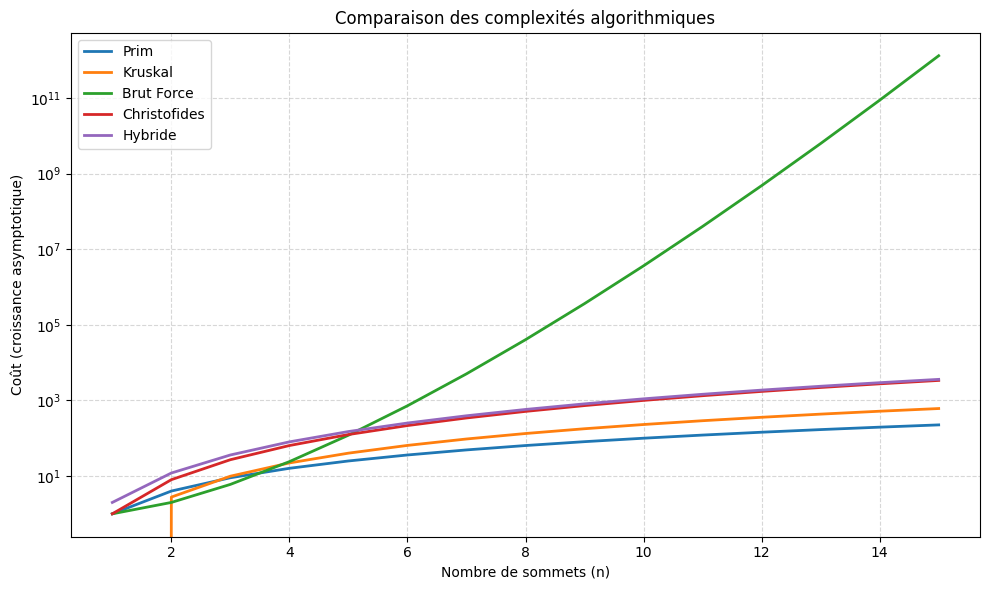

In [ ]:
plot_complexity_comparison(
    [
        lambda n: n**2,                  # Prim
        lambda n: n**2 * math.log(n),    # Kruskal
        lambda n: math.factorial(n),     # Brute Force
        lambda n: n**3,                  # Christofides
        lambda n: n**3 + n**2            # Hybride (Christofides + Insertion gloutonne)
    ],
    ["Prim", "Kruskal", "Brut Force", "Christofides", "Hybride"],
    n_max=15
)
